## Procesado de datos financieros de alta frecuencia para ML

Este notebook implementa un pipeline de preprocesado de datos financieros de alta frecuencia para BTC/USDT (datos de 1 minuto) siguiendo un enfoque inspirado en Marcos López de Prado. El objetivo es transformar datos brutos en una estructura adecuada para modelos de machine learning, respetando la naturaleza temporal y el ruido propio de los mercados financieros.

**Resumen de las etapas del pipeline:**
- **Sección 0**: Setup, parámetros globales y carga inicial de datos.
- **Sección 1**: Construcción y comparación de barras alternativas (tick, volumen, dólar) y selección de dollar bars.
- **Sección 2**: Diferenciación fraccional de la serie de precios y elección del grado de diferenciación.
- **Sección 3**: Construcción de features internas y limpieza de la matriz de covarianza mediante eigenvalue clipping.
- **Sección 4**: Etiquetado de eventos con el método de triple barrera (thresholds fijos y dinámicos).
- **Sección 5**: Definición de esquemas de validación cruzada temporal (70/30, 80/20, 90/10).


## 0. Setup global del entorno

En esta sección se importan las librerías básicas y se fijan los parámetros globales del análisis. 


In [95]:
# Imports básicos del proyecto
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns  # Para visualización de distribuciones de retornos
from statsmodels.tsa.stattools import adfuller  # Para test ADF de estacionariedad

# Configuración de estilo básica para las figuras de matplotlib
plt.style.use("default")  # Fondo blanco por defecto

# ======================================================================
# ### PARÁMETROS ###
# ----------------------------------------------------------------------
# Rango temporal de análisis (el usuario solo debería modificar estas dos
# variables para cambiar el periodo de trabajo del notebook).
# ======================================================================
DATE_START = "2026-02-01"
DATE_END   = "2026-02-28"

print("Rango temporal configurado:")
print(f"  Fecha inicio: {DATE_START}")
print(f"  Fecha fin   : {DATE_END}")

Rango temporal configurado:
  Fecha inicio: 2026-02-01
  Fecha fin   : 2026-02-28


### 0.1. Descarga y localización del archivo de datos

En esta sección se descarga el dataset histórico de BTC/USDT desde Kaggle mediante `kagglehub` y se localiza de forma automática el archivo CSV correcto dentro de la carpeta descargada. 

In [14]:
# Descarga del dataset de Kaggle y localización del archivo CSV principal

# Código de descarga fijado por el enunciado (no modificar)
import kagglehub
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
print("Path to dataset files:", path)

# Búsqueda recursiva de todos los archivos CSV dentro del path descargado
csv_pattern = os.path.join(path, "**", "*.csv")
csv_files = glob.glob(csv_pattern, recursive=True)

if not csv_files:
    raise FileNotFoundError("No se encontraron archivos CSV en la ruta descargada de Kaggle.")

print("\nArchivos CSV encontrados:")
for f in csv_files:
    print("  -", f)

# Estrategia de selección del archivo principal:
# 1) Preferir archivos cuyo nombre contenga referencias a BTCUSD/BTCUSDT.
# 2) Si no se encuentra ninguno, seleccionar el CSV de mayor tamaño (en bytes).

preferred_keywords = ["btcusd", "btcusdt", "btc_usd", "btc-usd"]

candidates_preferred = []
for f in csv_files:
    name_lower = os.path.basename(f).lower()
    if any(kw in name_lower for kw in preferred_keywords):
        candidates_preferred.append(f)

if candidates_preferred:
    # Si hay varios candidatos preferidos, elegir el más grande por tamaño
    csv_path = max(candidates_preferred, key=lambda p: os.path.getsize(p))
    strategy = "archivo con nombre que coincide con BTCUSD/BTCUSDT"
else:
    # Si no hay coincidencias en el nombre, elegir el CSV más grande en general
    csv_path = max(csv_files, key=lambda p: os.path.getsize(p))
    strategy = "archivo CSV de mayor tamaño (fallback)"

print("\nArchivo CSV seleccionado (", strategy, "):", sep="")
print("  ", csv_path)

# Guardamos la ruta seleccionada en una variable global para reutilizarla después
DATA_CSV_PATH = csv_path

Path to dataset files: C:\Users\Usuario\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\538

Archivos CSV encontrados:
  - C:\Users\Usuario\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\538\btcusd_1-min_data.csv

Archivo CSV seleccionado (archivo con nombre que coincide con BTCUSD/BTCUSDT):
   C:\Users\Usuario\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\538\btcusd_1-min_data.csv


### 0.2. Carga del CSV e inspección inicial del dataset

En esta sección se carga el archivo CSV seleccionado en un `DataFrame` de `pandas` y se realiza una inspección inicial básica (forma, tipos de datos, primeras y últimas filas). También se detecta de forma robusta cuál es la columna temporal y se comprueba si los datos están ordenados de forma cronológica o inversa.



In [16]:
# Carga del CSV seleccionado y exploración básica

# Leemos el archivo CSV seleccionado en la celda anterior
print("Leyendo CSV desde:")
print("  ", DATA_CSV_PATH)

df_raw = pd.read_csv(DATA_CSV_PATH)

print("\nDimensiones del DataFrame bruto:")
print("  shape =", df_raw.shape)

print("\nTipos de datos (dtypes):")
print(df_raw.dtypes)

print("\nPrimeras 3 filas:")
display(df_raw.head(3))

print("\nÚltimas 3 filas:")
display(df_raw.tail(3))

print("\nResumen df.info():")
df_raw.info()

# ----------------------------------------------------------------------
# Detección robusta de la columna temporal
# ----------------------------------------------------------------------

possible_time_names = [
    "timestamp", "date", "time", "datetime", "open time", "open_time"
]

# Buscamos coincidencias case-insensitive y permitimos espacios/guiones bajos
lower_cols = {col.lower(): col for col in df_raw.columns}

found_time_col = None
for candidate in possible_time_names:
    for col_lower, col_original in lower_cols.items():
        if candidate in col_lower:
            found_time_col = col_original
            break
    if found_time_col is not None:
        break

if found_time_col is None:
    raise ValueError(
        "No se pudo detectar una columna temporal. Revise los nombres de columna "
        "y actualice la lista de posibles variantes."
    )

print("\nColumna temporal detectada:")
print("  ", found_time_col)

# ----------------------------------------------------------------------
# Detección de si el orden temporal está invertido
# ----------------------------------------------------------------------

# Tomamos algunas muestras del principio y del final para intentar inferir el orden
sample_start = df_raw[found_time_col].head(5)
sample_end = df_raw[found_time_col].tail(5)

# Intentamos convertir estas muestras a datetime de forma flexible
sample_start_dt = pd.to_datetime(sample_start, errors="coerce")
sample_end_dt = pd.to_datetime(sample_end, errors="coerce")

is_reverse_order = False
if not sample_start_dt.isna().all() and not sample_end_dt.isna().all():
    first_ts = sample_start_dt.iloc[0]
    last_ts = sample_end_dt.iloc[-1]
    if pd.notna(first_ts) and pd.notna(last_ts):
        is_reverse_order = first_ts > last_ts

if is_reverse_order:
    print("\nOrden temporal detectado: INVERSO (últimas fechas primero). Se corregirá en la etapa de limpieza temporal.")
else:
    print("\nOrden temporal detectado: CRONOLÓGICO o no claramente inverso (se confirmará tras la conversión a datetime).")

# Guardamos el nombre de la columna temporal para usarlo en la siguiente fase
time_column_name = found_time_col

Leyendo CSV desde:
   C:\Users\Usuario\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\538\btcusd_1-min_data.csv

Dimensiones del DataFrame bruto:
  shape = (7467523, 6)

Tipos de datos (dtypes):
Timestamp    float64
Open         float64
High         float64
Low          float64
Close        float64
Volume       float64
dtype: object

Primeras 3 filas:


,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0



Últimas 3 filas:


,Timestamp,Open,High,Low,Close,Volume
7467520,1.773533e+09,71201.0,71202.0,71125.0,71125.0,1.149674
7467521,1.773533e+09,71121.0,71122.0,71116.0,71116.0,1.299773
7467522,1.773533e+09,71117.0,71125.0,71117.0,71118.0,1.561211



Resumen df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7467523 entries, 0 to 7467522
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 341.8 MB

Columna temporal detectada:
   Timestamp

Orden temporal detectado: CRONOLÓGICO o no claramente inverso (se confirmará tras la conversión a datetime).


### 0.3. Limpieza temporal y estandarización de columnas OHLCV

En esta sección se normaliza la dimensión temporal del dataset: se convierte la columna temporal detectada a tipo `datetime`, se renombra a un nombre estándar (`datetime`), se establece como índice y se ordena cronológicamente. Además, se estandarizan los nombres de las columnas OHLCV a formato `open`, `high`, `low`, `close`, `volume`.



In [17]:
# Limpieza temporal y estandarización de columnas OHLCV

if 'df_raw' not in globals():
    raise RuntimeError("df_raw no está definido. Ejecute primero las celdas de descarga y carga del CSV.")

# Copiamos el DataFrame bruto para trabajar sobre una versión intermedia
df = df_raw.copy()

# ----------------------------------------------------------------------
# Conversión de la columna temporal a datetime y renombrado estándar
# ----------------------------------------------------------------------

time_series = df[time_column_name]

# Detectamos si la columna temporal es numérica (posible Unix timestamp)
if pd.api.types.is_numeric_dtype(time_series):
    # Asumimos Unix timestamp en segundos, según la especificación del enunciado
    df['datetime'] = pd.to_datetime(time_series, unit='s', errors='coerce')
else:
    # Asumimos strings o tipos ya convertibles a datetime
    df['datetime'] = pd.to_datetime(time_series, errors='coerce', infer_datetime_format=True)

# Comprobamos si hay conversiones fallidas
n_invalid_dt = df['datetime'].isna().sum()
if n_invalid_dt > 0:
    print(f"Advertencia: {n_invalid_dt} filas tienen fecha/hora no convertible y se eliminarán.")
    df = df.dropna(subset=['datetime'])

# Establecemos 'datetime' como índice
df = df.drop(columns=[time_column_name])  # Eliminamos la columna original

# Orden cronológico ascendente
df = df.set_index('datetime').sort_index()

print("Índice temporal estandarizado a 'datetime' y ordenado cronológicamente.")

# ----------------------------------------------------------------------
# Estandarización de nombres de columnas OHLCV
# ----------------------------------------------------------------------

# Mapeo genérico de patrones a nombres estándar
ohlcv_targets = {
    'open': ['open'],
    'high': ['high', 'high_price'],
    'low':  ['low', 'low_price'],
    'close': ['close', 'close_price', 'price'],
    'volume': ['volume', 'volume_(btc)', 'volume_(currency)', 'vol']
}

col_mapping = {}
remaining_cols = list(df.columns)

for target_name, patterns in ohlcv_targets.items():
    found_col = None
    for col in remaining_cols:
        col_lower = col.lower()
        for pattern in patterns:
            if pattern in col_lower:
                found_col = col
                break
        if found_col is not None:
            break
    if found_col is not None:
        col_mapping[found_col] = target_name
        remaining_cols.remove(found_col)

# Renombramos las columnas encontradas
if col_mapping:
    df = df.rename(columns=col_mapping)

print("\nMapa de renombrado aplicado a columnas OHLCV:")
for orig, new in col_mapping.items():
    print(f"  {orig} -> {new}")

# ----------------------------------------------------------------------
# Eliminación de columnas no OHLCV
# ----------------------------------------------------------------------

cols_ohlcv = ['open', 'high', 'low', 'close', 'volume']

cols_present = [c for c in cols_ohlcv if c in df.columns]
if len(cols_present) < len(cols_ohlcv):
    missing = [c for c in cols_ohlcv if c not in df.columns]
    print("\nAdvertencia: faltan algunas columnas OHLCV esperadas:", missing)

# Seleccionamos solo las columnas OHLCV disponibles
cols_to_keep = cols_present

# Comentario: nos quedamos únicamente con OHLCV porque el objetivo de esta fase
# es trabajar con precios y volúmenes básicos; columnas auxiliares como
# 'Volume_(Currency)' o 'Weighted_Price' se descartan para simplificar el
# preprocesado y evitar duplicar información altamente correlacionada.

df = df[cols_to_keep]

print("\nColumnas finales tras la estandarización OHLCV:")
print(list(df.columns))

# Mostramos un pequeño resumen para verificar el resultado
print("\nResumen tras la limpieza temporal y estandarización OHLCV:")
print("  shape =", df.shape)
print("  Índice (datetime) desde", df.index.min(), "hasta", df.index.max())

Índice temporal estandarizado a 'datetime' y ordenado cronológicamente.

Mapa de renombrado aplicado a columnas OHLCV:
  Open -> open
  High -> high
  Low -> low
  Close -> close
  Volume -> volume

Columnas finales tras la estandarización OHLCV:
['open', 'high', 'low', 'close', 'volume']

Resumen tras la limpieza temporal y estandarización OHLCV:
  shape = (7467523, 5)
  Índice (datetime) desde 2012-01-01 10:01:00 hasta 2026-03-15 00:03:00


### 0.4. Filtrado temporal parametrizable con DATE_START y DATE_END

En esta sección se aplica el filtrado temporal sobre el índice `datetime` utilizando los parámetros globales `DATE_START` y `DATE_END`. El objetivo es trabajar únicamente con una ventana de datos coherente y controlada (por ejemplo, un mes de datos de 1 minuto).


In [18]:
# Filtrado temporal usando DATE_START y DATE_END

if 'df' not in globals():
    raise RuntimeError("df no está definido. Ejecute antes la celda de limpieza temporal (sección 3).")

# Convertimos las fechas de los parámetros globales a datetime
start_dt = pd.to_datetime(DATE_START)
end_dt = pd.to_datetime(DATE_END)

# Aplicamos el filtrado sobre el índice datetime
mask = (df.index >= start_dt) & (df.index <= end_dt)
df_window = df.loc[mask].copy()

if df_window.empty:
    raise ValueError(
        f"El filtrado temporal con DATE_START={DATE_START} y DATE_END={DATE_END} "
        "ha producido un DataFrame vacío. Revise el rango de fechas."
    )

n_rows = len(df_window)
print("Número de registros tras el filtrado temporal:", n_rows)
print("Rango real de fechas en la ventana filtrada:")
print("  Fecha mínima:", df_window.index.min())
print("  Fecha máxima:", df_window.index.max())

Número de registros tras el filtrado temporal: 38881
Rango real de fechas en la ventana filtrada:
  Fecha mínima: 2026-02-01 00:00:00
  Fecha máxima: 2026-02-28 00:00:00


### 0.5. Revisión de calidad del DataFrame filtrado

En esta sección se revisa la calidad del `DataFrame` ya filtrado temporalmente: se contabilizan valores ausentes, se aplican imputaciones controladas (forward fill limitado) sobre las columnas OHLCV cuando sea necesario y se detectan posibles duplicados en el índice temporal.

El objetivo es dejar constancia de los problemas de calidad encontrados y de las decisiones de limpieza tomadas.

In [19]:
# Revisión de calidad: NaNs, imputación controlada y duplicados

if 'df_window' not in globals():
    raise RuntimeError("df_window no está definido. Ejecute antes la celda de filtrado temporal (sección 4).")

# Trabajamos sobre una copia para la limpieza de calidad
df_clean = df_window.copy()

print("Valores ausentes por columna (antes de la imputación):")
na_before = df_clean.isna().sum()
print(na_before)

# Imputación forward fill limitada en columnas OHLCV si existen NaNs
cols_ohlcv = [c for c in ['open', 'high', 'low', 'close', 'volume'] if c in df_clean.columns]

if cols_ohlcv:
    # Contamos NaNs antes de imputar solo en OHLCV
    na_before_ohlcv = df_clean[cols_ohlcv].isna().sum().sum()

    if na_before_ohlcv > 0:
        print(f"\nAplicando forward fill (ffill) con límite de 5 periodos en columnas OHLCV (NaNs iniciales: {na_before_ohlcv}).")
        df_clean[cols_ohlcv] = df_clean[cols_ohlcv].ffill(limit=5)

        na_after_ohlcv = df_clean[cols_ohlcv].isna().sum().sum()
        imputed = na_before_ohlcv - na_after_ohlcv
        print(f"NaNs imputados en OHLCV: {imputed}")
        print(f"NaNs restantes en OHLCV tras imputación: {na_after_ohlcv}")
    else:
        print("\nNo se detectaron NaNs en columnas OHLCV. No se aplica imputación.")
else:
    print("\nAdvertencia: no se encontraron columnas OHLCV estándar para imputar (open, high, low, close, volume).")

# Recuento de NaNs final (todas las columnas)
print("\nValores ausentes por columna (después de la imputación):")
na_after = df_clean.isna().sum()
print(na_after)

# Detección de duplicados en el índice temporal
n_duplicated = df_clean.index.duplicated().sum()

if n_duplicated > 0:
    print(f"\nAdvertencia: se detectaron {n_duplicated} índices datetime duplicados.")
    # Podríamos decidir cómo resolverlos; por ahora solo se informa.
else:
    print("\nNo se detectaron índices datetime duplicados.")

print("\nResumen final de calidad tras esta sección:")
print("  shape =", df_clean.shape)
print("  Rango de fechas =", df_clean.index.min(), "→", df_clean.index.max())
print("  NaNs totales restantes =", int(df_clean.isna().sum().sum()))

Valores ausentes por columna (antes de la imputación):
open      0
high      0
low       0
close     0
volume    0
dtype: int64

No se detectaron NaNs en columnas OHLCV. No se aplica imputación.

Valores ausentes por columna (después de la imputación):
open      0
high      0
low       0
close     0
volume    0
dtype: int64

No se detectaron índices datetime duplicados.

Resumen final de calidad tras esta sección:
  shape = (38881, 5)
  Rango de fechas = 2026-02-01 00:00:00 → 2026-02-28 00:00:00
  NaNs totales restantes = 0


### 0.6. DataFrame final listo para la siguiente fase
En esta sección se muestra un resumen final del `DataFrame` limpio y filtrado que se utilizará como punto de partida para la construcción de barras alternativas en fases posteriores. Se imprimen las primeras filas y la estructura de tipos para verificar que la información relevante (OHLCV e índice temporal) está en el formato esperado.

Cerrar esta fase con una confirmación explícita del estado del `DataFrame` ayuda a documentar que los datos están listos para ser transformados sin necesidad de rehacer el preprocesado previo.

In [21]:
# Resumen final del DataFrame limpio y filtrado

if 'df_clean' not in globals():
    raise RuntimeError("df_clean no está definido. Asegúrese de haber ejecutado las celdas anteriores.")

print("DataFrame final (df_clean): primeras 5 filas:")
display(df_clean.head())

print("\nEstructura de df_clean (info):")
df_clean.info()

print("\nConfirmación:")
print("El DataFrame df_clean está limpio, filtrado en el rango temporal especificado y listo para la construcción de barras alternativas en la siguiente fase del pipeline.")

DataFrame final (df_clean): primeras 5 filas:


,open,high,low,close,volume
datetime,,,,,
2026-02-01 00:00:00,78644.0,78669.0,78591.0,78591.0,4.752846
2026-02-01 00:01:00,78591.0,78591.0,78556.0,78572.0,10.587024
2026-02-01 00:02:00,78571.0,78721.0,78571.0,78721.0,3.881749
2026-02-01 00:03:00,78721.0,78799.0,78707.0,78786.0,6.234550
2026-02-01 00:04:00,78778.0,78830.0,78757.0,78816.0,1.310776



Estructura de df_clean (info):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38881 entries, 2026-02-01 00:00:00 to 2026-02-28 00:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    38881 non-null  float64
 1   high    38881 non-null  float64
 2   low     38881 non-null  float64
 3   close   38881 non-null  float64
 4   volume  38881 non-null  float64
dtypes: float64(5)
memory usage: 1.8 MB

Confirmación:
El DataFrame df_clean está limpio, filtrado en el rango temporal especificado y listo para la construcción de barras alternativas en la siguiente fase del pipeline.


## 1. Construcción y comparación de barras alternativas

**Propósito**: Transformar la serie de 1 minuto en representaciones alternativas (tick bars, volume bars y dollar bars) y justificar la elección de dollar bars como base para el resto del pipeline.

En series financieras de alta frecuencia, las barras equiespaciadas en tiempo pueden no representar adecuadamente la actividad real del mercado, ya que periodos con distinta intensidad de negociación reciben el mismo peso temporal. Para reducir este efecto, se construyen barras alternativas que agrupan observaciones según criterios de actividad.

| Tipo de barra | Criterio de construcción | Motivación principal | Limitación en este caso |
|---------------|--------------------------|----------------------|--------------------------|
| **Tick Bars** | Agrupan un número fijo de observaciones | Homogeneizar número de eventos por barra | Se aproxima usando datos de 1 minuto, no ticks reales |
| **Volume Bars** | Agrupan hasta acumular un volumen fijo | Igualar actividad negociada | Dependencia del umbral elegido |
| **Dollar Bars** | Agrupan hasta acumular precio × volumen fijo | Capturar flujo de capital negociado | Sensibles a cambios bruscos de precio |

A partir del dataframe de BTC/USDT de 1 minuto se generan tres nuevas series OHLCV aplicando umbrales parametrizables para cada método. Cada barra reconstruye:

- **Open:** primer precio del grupo  
- **High:** máximo precio  
- **Low:** mínimo precio  
- **Close:** último precio  
- **Volume:** volumen total acumulado  

Posteriormente se comparan:

- número total de barras generadas  
- series temporales de precios de cierre  
- distribución de retornos por tipo de barra  

Finalmente se seleccionará **Dollar Bars** como representación base para continuar el pipeline, al aproximar mejor la actividad económica del mercado.

### 1.0. Parametros barras alternativas

In [66]:
# Parámetros específicos para la Fase 2: construcción de barras alternativas

# Estos valores sirven como punto de partida razonable para un mes de datos
# de 1 minuto en BTC/USDT. Si el periodo tiene muy poca actividad (pocas
# barras resultantes), puede ser necesario reducir los umbrales; si hay
# demasiadas barras, puede aumentarse su valor.

TICK_SIZE        = 10       # número de ticks (minutos) por barra de tipo tick
VOLUME_THRESHOLD = 10.0      # BTC acumulados por barra de tipo volumen
DOLLAR_THRESHOLD = 500_000.0 # USD acumulados por barra de tipo dólar

print("Parámetros Fase 1:")
print(f"  TICK_SIZE        = {TICK_SIZE}")
print(f"  VOLUME_THRESHOLD = {VOLUME_THRESHOLD}")
print(f"  DOLLAR_THRESHOLD = {DOLLAR_THRESHOLD}")

Parámetros Fase 1:
  TICK_SIZE        = 10
  VOLUME_THRESHOLD = 10.0
  DOLLAR_THRESHOLD = 500000.0


### 1.1. Tick Bars
Las **tick bars** agrupan un número fijo de observaciones consecutivas del DataFrame original (definido por `tick_size`).  


In [67]:
def tick_bars(df, tick_size):
    """Construye tick bars a partir de un DataFrame OHLCV con frecuencia fija.

    Cada barra agrupa `tick_size` observaciones consecutivas del DataFrame
    original. La barra resultante tiene:
    - open  = primer precio de apertura del grupo
    - high  = máximo de máximos del grupo
    - low   = mínimo de mínimos del grupo
    - close = último precio de cierre del grupo
    - volume = suma de volúmenes del grupo

    El índice de cada barra es el datetime del primer tick del grupo.
    """
    if tick_size <= 0:
        raise ValueError("tick_size debe ser un entero positivo.")

    if df.empty:
        raise ValueError("El DataFrame de entrada está vacío.")

    rows = []
    n = len(df)

    # Recorremos el DataFrame en bloques consecutivos de tamaño tick_size
    for start in range(0, n, tick_size):
        end = start + tick_size
        chunk = df.iloc[start:end]

        if chunk.empty:
            continue

        idx_bar = chunk.index[0]  # datetime del primer tick del grupo

        open_price = float(chunk['open'].iloc[0])
        high_price = float(chunk['high'].max())
        low_price = float(chunk['low'].min())
        close_price = float(chunk['close'].iloc[-1])
        volume_sum = float(chunk['volume'].sum())

        rows.append({
            'datetime': idx_bar,
            'open': open_price,
            'high': high_price,
            'low': low_price,
            'close': close_price,
            'volume': volume_sum,
        })

    df_tick = pd.DataFrame(rows).set_index('datetime')

    n_bars = len(df_tick)
    print(f"Tick bars generadas: {n_bars} barras")
    if n_bars < 20:
        print("Advertencia: se han generado menos de 20 tick bars. Considere reducir TICK_SIZE.")

    return df_tick

### 1.2. Volume Bars

Las **volume bars** se construyen acumulando operaciones hasta que se alcance un **volumen total específico** (`volume_threshold`).  
Cada barra representa aproximadamente la misma cantidad de actividad de mercado, independientemente del tiempo.  

In [68]:
def volume_bars(df, volume_threshold):
    """Construye volume bars a partir de un DataFrame OHLCV con frecuencia fija.

    Cada barra agrupa observaciones consecutivas hasta que el volumen acumulado
    supera `volume_threshold`. La barra resultante tiene OHLCV definido como:
    - open  = primer precio de apertura del grupo
    - high  = máximo de máximos del grupo
    - low   = mínimo de mínimos del grupo
    - close = último precio de cierre del grupo
    - volume = suma de volúmenes del grupo

    El índice de cada barra es el datetime del primer tick del grupo.
    """
    if volume_threshold <= 0:
        raise ValueError("volume_threshold debe ser positivo.")

    if df.empty:
        raise ValueError("El DataFrame de entrada está vacío.")

    rows = []
    current_start_idx = None
    accumulated_volume = 0.0

    for idx, row in df.iterrows():
        # Inicializamos el inicio del grupo si es la primera fila del grupo
        if current_start_idx is None:
            current_start_idx = idx

        accumulated_volume += float(row['volume'])

        # Comprobamos si hemos alcanzado o superado el umbral de volumen
        if accumulated_volume >= volume_threshold:
            # Extraemos el grupo desde current_start_idx hasta el índice actual
            chunk = df.loc[current_start_idx:idx]

            open_price = float(chunk['open'].iloc[0])
            high_price = float(chunk['high'].max())
            low_price = float(chunk['low'].min())
            close_price = float(chunk['close'].iloc[-1])
            volume_sum = float(chunk['volume'].sum())

            rows.append({
                'datetime': current_start_idx,
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': volume_sum,
            })

            # Reiniciamos acumulador y comienzo del siguiente grupo
            accumulated_volume = 0.0
            current_start_idx = None

    # Si queda un grupo parcial al final, podemos decidir si conservarlo
    # En este caso lo conservamos si tiene más de una observación.
    if current_start_idx is not None:
        chunk = df.loc[current_start_idx:df.index[-1]]
        if len(chunk) > 0:
            open_price = float(chunk['open'].iloc[0])
            high_price = float(chunk['high'].max())
            low_price = float(chunk['low'].min())
            close_price = float(chunk['close'].iloc[-1])
            volume_sum = float(chunk['volume'].sum())

            rows.append({
                'datetime': current_start_idx,
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': volume_sum,
            })

    df_volume = pd.DataFrame(rows).set_index('datetime')

    n_bars = len(df_volume)
    print(f"Volume bars generadas: {n_bars} barras")
    if n_bars < 20:
        print("Advertencia: se han generado menos de 20 volume bars. Considere reducir VOLUME_THRESHOLD.")

    return df_volume

### 1.3. Dollar Bars

Las **dollar bars** agrupan operaciones hasta alcanzar un **valor monetario total** (`dollar_threshold`).  
Se calcula como el **precio × volumen** de cada tick, acumulando hasta que se supera el umbral.

In [70]:
def dollar_bars(df, dollar_threshold):
    """Construye dollar bars a partir de un DataFrame OHLCV con frecuencia fija.

    Cada barra agrupa observaciones consecutivas hasta que el volumen nocional
    acumulado (precio de cierre × volumen) supera `dollar_threshold`. La barra
    resultante tiene OHLCV definido como:
    - open  = primer precio de apertura del grupo
    - high  = máximo de máximos del grupo
    - low   = mínimo de mínimos del grupo
    - close = último precio de cierre del grupo
    - volume = suma de volúmenes del grupo

    El índice de cada barra es el datetime del primer tick del grupo.
    """
    if dollar_threshold <= 0:
        raise ValueError("dollar_threshold debe ser positivo.")

    if df.empty:
        raise ValueError("El DataFrame de entrada está vacío.")

    rows = []
    current_start_idx = None
    accumulated_dollars = 0.0

    for idx, row in df.iterrows():
        if current_start_idx is None:
            current_start_idx = idx

        # Volumen nocional: precio de cierre × volumen
        dollar_volume = float(row['close']) * float(row['volume'])
        accumulated_dollars += dollar_volume

        if accumulated_dollars >= dollar_threshold:
            chunk = df.loc[current_start_idx:idx]

            open_price = float(chunk['open'].iloc[0])
            high_price = float(chunk['high'].max())
            low_price = float(chunk['low'].min())
            close_price = float(chunk['close'].iloc[-1])
            volume_sum = float(chunk['volume'].sum())

            rows.append({
                'datetime': current_start_idx,
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': volume_sum,
            })

            accumulated_dollars = 0.0
            current_start_idx = None

    # Grupo parcial final (si existe)
    if current_start_idx is not None:
        chunk = df.loc[current_start_idx:df.index[-1]]
        if len(chunk) > 0:
            open_price = float(chunk['open'].iloc[0])
            high_price = float(chunk['high'].max())
            low_price = float(chunk['low'].min())
            close_price = float(chunk['close'].iloc[-1])
            volume_sum = float(chunk['volume'].sum())

            rows.append({
                'datetime': current_start_idx,
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': volume_sum,
            })

    df_dollar = pd.DataFrame(rows).set_index('datetime')

    n_bars = len(df_dollar)
    print(f"Dollar bars generadas: {n_bars} barras")
    if n_bars < 20:
        print("Advertencia: se han generado menos de 20 dollar bars. Considere reducir DOLLAR_THRESHOLD.")

    return df_dollar

### 1.4. Construcción práctica de tick, volume y dollar bars

En esta sección se aplican las tres funciones definidas anteriormente al `DataFrame` base de 1 minuto para generar `df_tick`, `df_volume` y `df_dollar`. Se resume cuántas barras produce cada método y el rango temporal que cubren, lo que ayuda a diagnosticar si los parámetros elegidos (tamaño de tick, umbrales de volumen y dólar) son razonables.

El objetivo es obtener una primera verificación de que las barras alternativas se han construido correctamente antes de pasar a las comparaciones visuales y de distribución de retornos.

In [71]:
# Seleccionamos el DataFrame base. Según el enunciado, partimos de `df`
if 'df' in globals():
    df_base = df
elif 'df_clean' in globals():
    df_base = df_clean
else:
    raise RuntimeError("No se ha encontrado un DataFrame base llamado 'df' o 'df_clean'.")

# Filtramos solo el rango de fechas definido en DATE_START y DATE_END
df_base_filtered = df_base.loc[DATE_START:DATE_END]

print("DataFrame base filtrado para barras alternativas:")
print("  shape =", df_base_filtered.shape)
print("  Rango de fechas =", df_base_filtered.index.min(), "→", df_base_filtered.index.max())

# Construimos las tres familias de barras usando solo el DataFrame filtrado
df_tick = tick_bars(df_base_filtered, TICK_SIZE)
df_volume = volume_bars(df_base_filtered, VOLUME_THRESHOLD)
df_dollar = dollar_bars(df_base_filtered, DOLLAR_THRESHOLD)

# Resumen de cada tipo de barra
print("\nResumen de barras generadas:")
for name, df_b in [("Tick bars", df_tick), ("Volume bars", df_volume), ("Dollar bars", df_dollar)]:
    if not df_b.empty:
        print(f"- {name}: {len(df_b)} barras, rango temporal {df_b.index.min()} → {df_b.index.max()}")
    else:
        print(f"- {name}: 0 barras (revisar parámetros).")

print("\nVista previa de las first dollar bars (df_dollar.head()):")
display(df_dollar.head())

DataFrame base filtrado para barras alternativas:
  shape = (40320, 5)
  Rango de fechas = 2026-02-01 00:00:00 → 2026-02-28 23:59:00
Tick bars generadas: 4032 barras
Volume bars generadas: 7983 barras
Dollar bars generadas: 9939 barras

Resumen de barras generadas:
- Tick bars: 4032 barras, rango temporal 2026-02-01 00:00:00 → 2026-02-28 23:50:00
- Volume bars: 7983 barras, rango temporal 2026-02-01 00:00:00 → 2026-02-28 23:57:00
- Dollar bars: 9939 barras, rango temporal 2026-02-01 00:00:00 → 2026-02-28 23:55:00

Vista previa de las first dollar bars (df_dollar.head()):


,open,high,low,close,volume
datetime,,,,,
2026-02-01 00:00:00,78644.0,78669.0,78556.0,78572.0,15.339870
2026-02-01 00:02:00,78571.0,78799.0,78571.0,78786.0,10.116298
2026-02-01 00:04:00,78778.0,78891.0,78757.0,78886.0,7.643620
2026-02-01 00:07:00,78885.0,78936.0,78830.0,78936.0,7.056879
2026-02-01 00:08:00,78936.0,79064.0,78934.0,79064.0,13.099359


### 1.5. Comparación visual y distribucional de las barras generadas

En esta sección se generan tres tipos de visualizaciones para comparar los métodos de construcción de barras: (i) el número total de barras por método, (ii) la forma de las series de precios de cierre y (iii) la distribución de los retornos logarítmicos. Estas vistas complementarias permiten evaluar tanto la densidad de información como el comportamiento estadístico de cada aproximación.

En particular, la comparación de las distribuciones de retornos proporciona evidencia empírica sobre qué tipo de barras genera retornos con colas menos extremas y una forma más regular, algo clave a la hora de seleccionar la representación base para modelos de ML financieros.

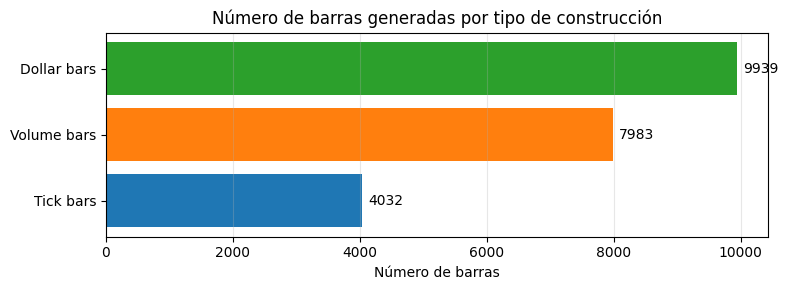

In [76]:
# Gráfica 1: número de barras por método

counts = {
    'Tick bars': len(df_tick),
    'Volume bars': len(df_volume),
    'Dollar bars': len(df_dollar),
}

methods = list(counts.keys())
values = list(counts.values())

y_pos = np.arange(len(methods))

fig, ax = plt.subplots(figsize=(8, 3))

ax.barh(y_pos, values, color=['tab:blue', 'tab:orange', 'tab:green'])
ax.set_yticks(y_pos)
ax.set_yticklabels(methods)
ax.set_xlabel('Número de barras')
ax.set_title('Número de barras generadas por tipo de construcción')

# Etiquetamos el número exacto a la derecha de cada barra
for i, v in enumerate(values):
    ax.text(v + max(values) * 0.01, i, str(v), va='center')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()


plt.show()

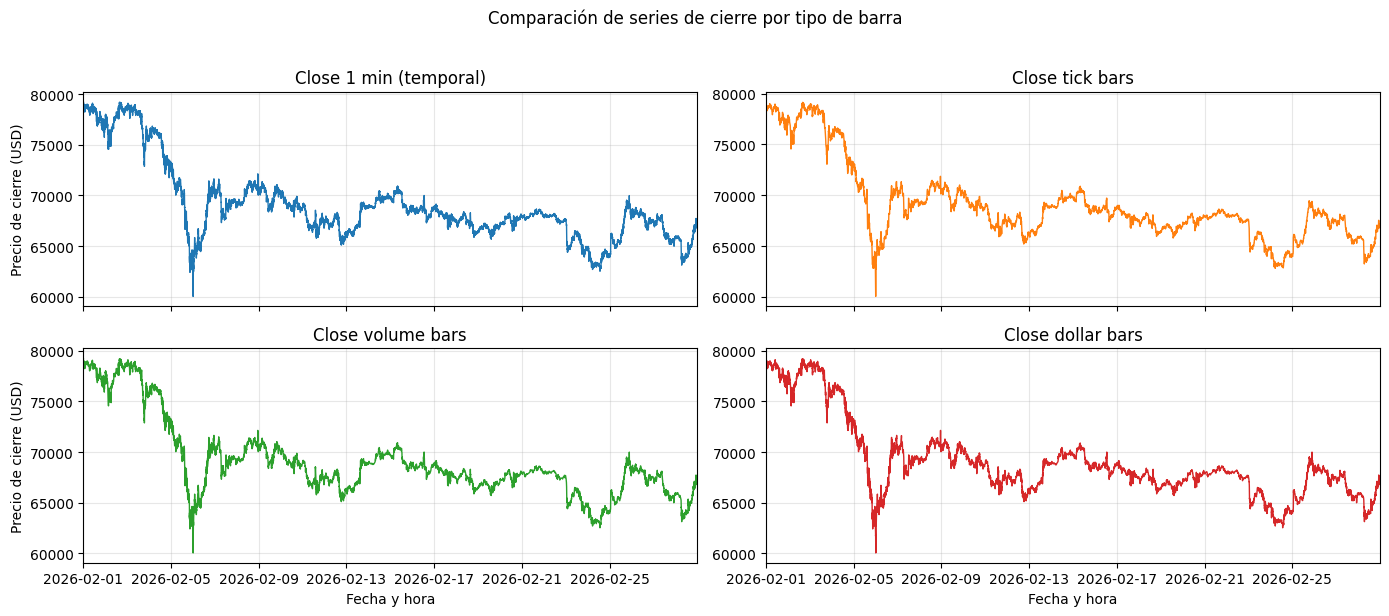

In [77]:
# Gráfica 2: comparación de las series de 'close' por método

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)
axes = axes.flatten()

# Determinamos rango temporal común basado en el DataFrame base
if 'df_base' not in globals():
    if 'df' in globals():
        df_base = df
    elif 'df_clean' in globals():
        df_base = df_clean
    else:
        raise RuntimeError("No se ha encontrado un DataFrame base para determinar el rango temporal.")

df_base_filtered = df_base.loc[DATE_START:DATE_END]

x_min = df_base_filtered.index.min()
x_max = df_base_filtered.index.max()

# 0) Serie original de 1 minuto
axes[0].plot(df_base_filtered.index, df_base_filtered['close'], color='tab:blue', linewidth=1)
axes[0].set_title('Close 1 min (temporal)')
axes[0].grid(alpha=0.3)

# 1) Tick bars
axes[1].plot(df_tick.index, df_tick['close'], color='tab:orange', linewidth=1)
axes[1].set_title('Close tick bars')
axes[1].grid(alpha=0.3)

# 2) Volume bars
axes[2].plot(df_volume.index, df_volume['close'], color='tab:green', linewidth=1)
axes[2].set_title('Close volume bars')
axes[2].grid(alpha=0.3)

# 3) Dollar bars
axes[3].plot(df_dollar.index, df_dollar['close'], color='tab:red', linewidth=1)
axes[3].set_title('Close dollar bars')
axes[3].grid(alpha=0.3)

for ax in axes:
    ax.set_xlim(x_min, x_max)

fig.suptitle('Comparación de series de cierre por tipo de barra', y=1.02)

for ax in axes[2:]:
    ax.set_xlabel('Fecha y hora')
for ax in [axes[0], axes[2]]:
    ax.set_ylabel('Precio de cierre (USD)')

plt.tight_layout()

plt.show()

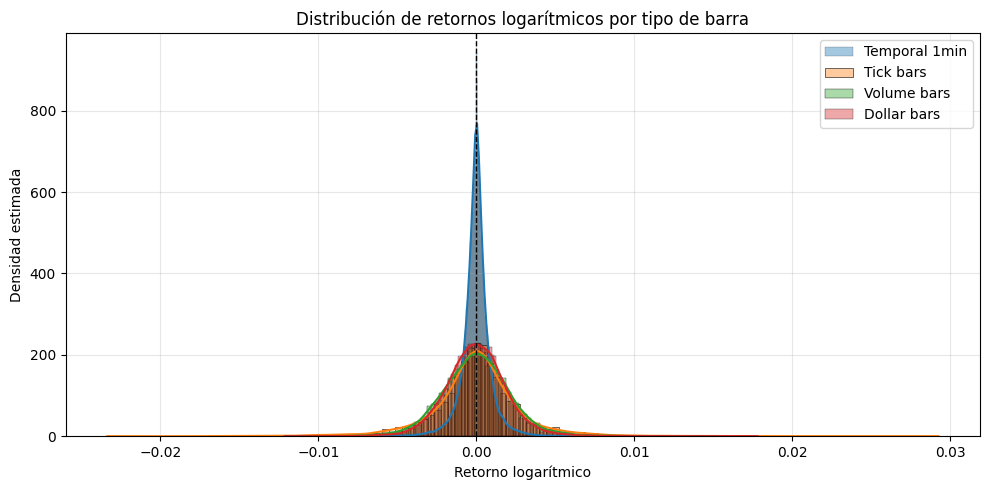

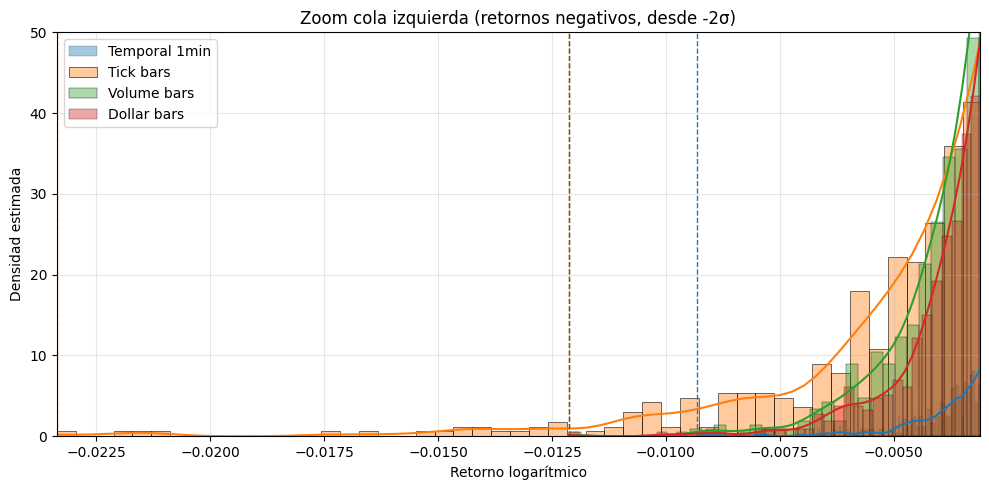

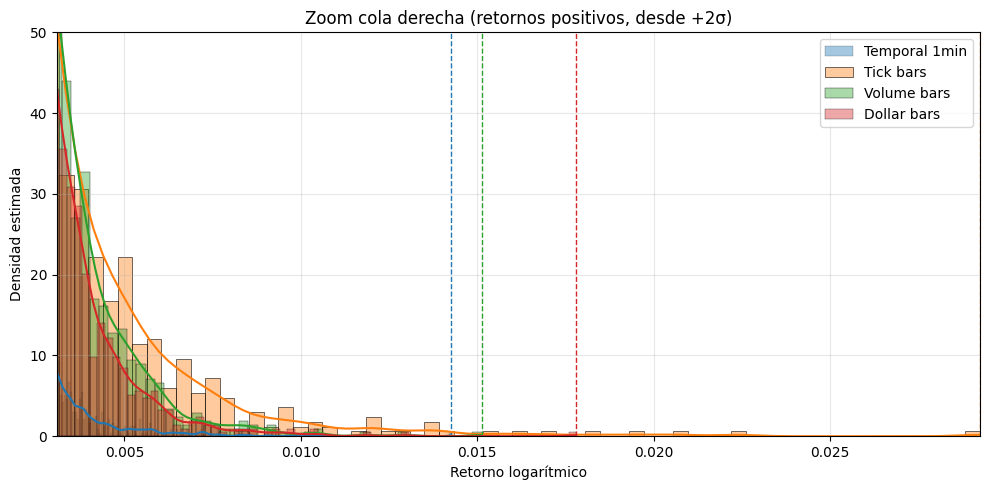

In [78]:
# Filtramos todos los DataFrames al rango de fechas DATE_START → DATE_END
df_temp_plot = df_base.loc[DATE_START:DATE_END]
df_tick_plot = df_tick.loc[DATE_START:DATE_END]
df_volume_plot = df_volume.loc[DATE_START:DATE_END]
df_dollar_plot = df_dollar.loc[DATE_START:DATE_END]

# Cálculo de retornos logarítmicos para cada serie
rets_temporal = np.log(df_temp_plot['close']).diff().dropna()
rets_tick = np.log(df_tick_plot['close']).diff().dropna()
rets_volume = np.log(df_volume_plot['close']).diff().dropna()
rets_dollar = np.log(df_dollar_plot['close']).diff().dropna()

# --- Gráfica 1: distribución completa ---
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(rets_temporal, kde=True, stat='density', label='Temporal 1min', color='tab:blue', alpha=0.4, ax=ax)
sns.histplot(rets_tick, kde=True, stat='density', label='Tick bars', color='tab:orange', alpha=0.4, ax=ax)
sns.histplot(rets_volume, kde=True, stat='density', label='Volume bars', color='tab:green', alpha=0.4, ax=ax)
sns.histplot(rets_dollar, kde=True, stat='density', label='Dollar bars', color='tab:red', alpha=0.4, ax=ax)

ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Distribución de retornos logarítmicos por tipo de barra')
ax.set_xlabel('Retorno logarítmico')
ax.set_ylabel('Densidad estimada')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Calculamos media y desviación estándar combinada para determinar los 2σ
all_rets = pd.concat([rets_temporal, rets_tick, rets_volume, rets_dollar])
mean_ret = all_rets.mean()
std_ret = all_rets.std()
two_std = 2 * std_ret

# --- Gráfica 2: zoom cola izquierda (retornos negativos desde -2σ) ---
fig, ax = plt.subplots(figsize=(10, 5))

# Lista de retornos y colores
rets_list = [rets_temporal, rets_tick, rets_volume, rets_dollar]
labels = ['Temporal 1min', 'Tick bars', 'Volume bars', 'Dollar bars']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for rets, label, color in zip(rets_list, labels, colors):
    sns.histplot(rets, kde=True, stat='density', label=label, color=color, alpha=0.4, ax=ax)
    # Línea vertical al final de cada distribución (mínimo para la cola izquierda)
    ax.axvline(rets.min(), color=color, linestyle='--', linewidth=1)

ax.set_xlim(all_rets.min(), mean_ret - two_std)
ax.set_ylim(0, 50)  # zoom en Y
ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Zoom cola izquierda (retornos negativos, desde -2σ)')
ax.set_xlabel('Retorno logarítmico')
ax.set_ylabel('Densidad estimada')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Gráfica 3: zoom cola derecha (retornos positivos desde +2σ) ---
fig, ax = plt.subplots(figsize=(10, 5))

for rets, label, color in zip(rets_list, labels, colors):
    sns.histplot(rets, kde=True, stat='density', label=label, color=color, alpha=0.4, ax=ax)
    # Línea vertical al final de cada distribución (máximo para la cola derecha)
    ax.axvline(rets.max(), color=color, linestyle='--', linewidth=1)

ax.set_xlim(mean_ret + two_std, all_rets.max())
ax.set_ylim(0, 50)  # zoom en Y
ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Zoom cola derecha (retornos positivos, desde +2σ)')
ax.set_xlabel('Retorno logarítmico')
ax.set_ylabel('Densidad estimada')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.6. Decisión final de la fase: selección de dollar bars

Las gráficas anteriores muestran cómo el número de barras y la forma de las series de precios dependen de la regla de construcción elegida. En general, las tick bars y volume bars ya mitigan en parte la irregularidad de la actividad frente a las barras temporales de 1 minuto, pero las dollar bars homogeneizan explícitamente el capital intercambiado en cada observación.

La comparación de las distribuciones de retornos sugiere que las dollar bars producen retornos con colas menos extremas y una forma más cercana a la normalidad, lo que suele ser deseable en muchos modelos de ML y técnicas estadísticas. Además, al medir la actividad en términos monetarios, las dollar bars son más robustas a cambios en el nivel de precios y en el patrón de volumen.

Siguiendo la recomendación de López de Prado (2018, Cap. 2) y la evidencia visual obtenida, **para el resto del pipeline utilizaremos `df_dollar` como representación base del proceso de precios**, copiándolo a una variable explícita (`df_bars`) que servirá como entrada estándar en las siguientes fases del notebook.

In [80]:

from scipy.stats import skew, kurtosis

# Creamos un diccionario con los retornos
rets_dict = {
    'Temporal 1min': rets_temporal,
    'Tick bars': rets_tick,
    'Volume bars': rets_volume,
    'Dollar bars': rets_dollar
}

# Calculamos estadísticas para cada tipo de barra
stats_list = []
for label, rets in rets_dict.items():
    stats_list.append({
        'Tipo de barra': label,
        'Media': rets.mean(),
        'Desviación estándar': rets.std(),
        'Asimetría (Skewness)': skew(rets),
        'Curtosis': kurtosis(rets)  # Fisher’s definition (0 = normal)
    })

# Convertimos a DataFrame
stats_df = pd.DataFrame(stats_list)

# Mostramos la tabla
pd.set_option('display.float_format', '{:.6f}'.format)
print("Estadísticas de los retornos logarítmicos por tipo de barra:")
display(stats_df)

Estadísticas de los retornos logarítmicos por tipo de barra:


,Tipo de barra,Media,Desviación estándar,Asimetría (Skewness),Curtosis
0,Temporal 1min,-0.000004,0.000955,0.353925,11.754356
1,Tick bars,-0.000041,0.003060,-0.058944,9.886278
2,Volume bars,-0.000020,0.002166,0.141183,1.691324
3,Dollar bars,-0.000016,0.001944,0.202193,2.629776


In [81]:
# DataFrame de barras seleccionado para el resto del pipeline

df_bars = df_dollar.copy()

print("df_bars asignado a partir de df_dollar. shape =", df_bars.shape)
print("Rango temporal =", df_bars.index.min(), "→", df_bars.index.max())

df_bars asignado a partir de df_dollar. shape = (9939, 5)
Rango temporal = 2026-02-01 00:00:00 → 2026-02-28 23:55:00


## 2. Diferenciación fraccional de la serie de precios

La diferenciación entera (d=1) elimina completamente la memoria de la serie para lograr estacionariedad, pero destruye información predictiva valiosa. La diferenciación fraccional (0 < d < 1) permite encontrar un equilibrio: series suficientemente estacionarias que conservan memoria a largo plazo, lo cual es crucial para modelos de ML que intentan capturar patrones temporales.

El trade-off fundamental es claro: a mayor valor de d, más estacionaria será la serie pero menos memoria conservará de la serie original. El objetivo práctico es encontrar el mínimo valor de d que logra estacionariedad aceptable (según un test estadístico como ADF) sin destruir más memoria de la necesaria.

El algoritmo Fixed-Width Window Fracdiff (FFD) recomendado por López de Prado (2018, Cap. 5) calcula los pesos mediante la fórmula recursiva:

$$w_k = \prod_{i=0}^{k-1} \frac{d - i}{i + 1}$$

donde $w_0 = 1$ y los pesos se truncan cuando su magnitud cae por debajo de un umbral. La serie diferenciada fraccionalmente se obtiene mediante convolución de estos pesos con la serie original.

### 2.1. Parámetros de diferenciación fraccional

En esta celda se definen los parámetros específicos para la Fase 2: los valores de d a explorar, el umbral para truncar pesos pequeños en el algoritmo FFD y el nivel de significancia para el test ADF de estacionariedad.

In [101]:
# ======================================================================
# ### PARÁMETROS FASE 3 ###
# ----------------------------------------------------------------------
# Parámetros para la diferenciación fraccional (Fixed-Width Window FFD).
# - D_VALUES: valores de d a explorar (0.0 = sin diferenciar, 1.0 = diferenciación entera).
# - FRACDIFF_THRESHOLD: umbral para truncar pesos pequeños (cuando |w_k| < threshold).
# - ADF_SIGNIFICANCE: nivel de significancia para el test ADF de estacionariedad.
# ======================================================================
D_VALUES          = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
FRACDIFF_THRESHOLD = 1e-4   # truncación de pesos en el algoritmo FFD
ADF_SIGNIFICANCE   = 0.05   # nivel de significancia para estacionariedad (p < 0.05)

print("Parámetros Fase 3:")
print(f"  D_VALUES          = {D_VALUES}")
print(f"  FRACDIFF_THRESHOLD = {FRACDIFF_THRESHOLD}")
print(f"  ADF_SIGNIFICANCE   = {ADF_SIGNIFICANCE}")

Parámetros Fase 3:
  D_VALUES          = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
  FRACDIFF_THRESHOLD = 0.0001
  ADF_SIGNIFICANCE   = 0.05


### 2.2. Implementación del algoritmo FFD

En esta sección se implementan las dos funciones principales del algoritmo Fixed-Width Window Fracdiff: `get_weights_ffd` (cálculo de pesos recursivos) y `frac_diff_ffd` (aplicación de la convolución sobre la serie). La implementación es manual y explícita para que quede clara la lógica del algoritmo sin depender de librerías externas especializadas.

El algoritmo FFD es preferible a otras variantes porque utiliza una ventana fija de pesos, lo que garantiza estabilidad numérica y permite controlar el número de observaciones iniciales que se pierden por la ventana de convolución.

In [102]:
def get_weights_ffd(d, threshold):
    """Calcula el vector de pesos para diferenciación fraccional usando FFD.

    Los pesos se calculan recursivamente según la fórmula:
        w_0 = 1
        w_k = -w_{k-1} * (d - k + 1) / k

    El cálculo se detiene cuando |w_k| < threshold.

    Parámetros:
    -----------
    d : float
        Grado de diferenciación fraccional (típicamente entre 0 y 1).
    threshold : float
        Umbral mínimo para truncar pesos pequeños.

    Retorna:
    --------
    np.ndarray
        Vector de pesos w_k, donde w[0] = 1.0.
    """
    weights = [1.0]  # w_0 = 1

    k = 1
    while True:
        # Fórmula recursiva: w_k = -w_{k-1} * (d - k + 1) / k
        w_k = -weights[-1] * (d - k + 1) / k

        if abs(w_k) < threshold:
            break

        weights.append(w_k)
        k += 1

    return np.array(weights)

In [103]:
def frac_diff_ffd(series, d, threshold):
    """Aplica diferenciación fraccional usando Fixed-Width Window FFD.

    Para cada punto t de la serie, calcula:
        x_t^d = sum_{k=0}^{l} w_k * x_{t-k}

    donde w_k son los pesos calculados por get_weights_ffd y l es la longitud
    de la ventana (número de pesos no truncados).

    Los primeros l valores de la serie resultante serán NaN porque no hay
    suficientes valores históricos para aplicar la convolución completa.

    Parámetros:
    -----------
    series : pd.Series
        Serie temporal a diferenciar (debe tener índice datetime).
    d : float
        Grado de diferenciación fraccional.
    threshold : float
        Umbral para truncar pesos pequeños.

    Retorna:
    --------
    pd.Series
        Serie diferenciada fraccionalmente, con mismo índice que la entrada.
        Los primeros valores serán NaN debido a la ventana de convolución.
    """
    if d == 0.0:
        # Sin diferenciación: devolver serie original
        return series.copy()

    # Calculamos los pesos
    weights = get_weights_ffd(d, threshold)
    l = len(weights) - 1  # Longitud de la ventana (sin contar w_0)

    # Convertimos la serie a array numpy para la convolución
    values = series.values
    n = len(values)

    # Inicializamos el resultado con NaNs
    result = np.full(n, np.nan)

    # Aplicamos la convolución para cada punto t >= l
    for t in range(l, n):
        # Convolución: sum_{k=0}^{l} w_k * x_{t-k}
        # Nota: w[0] corresponde a w_0, w[1] a w_1, etc.
        conv_sum = 0.0
        for k in range(len(weights)):
            idx = t - k
            if idx >= 0:
                conv_sum += weights[k] * values[idx]
        result[t] = conv_sum

    # Construimos la Serie de salida con el mismo índice
    result_series = pd.Series(result, index=series.index, name=series.name)

    return result_series

### 2.3. Evaluación de múltiples grados de diferenciación y test ADF

En esta sección se aplica la diferenciación fraccional a todos los valores de d especificados en `D_VALUES` y se evalúa cada serie resultante mediante el test Augmented Dickey-Fuller (ADF) para determinar su estacionariedad. Además, se calcula la correlación de cada serie diferenciada con la serie original para medir cuánta memoria se preserva.

El objetivo es construir una tabla resumen que permita identificar el menor valor de d que logra estacionariedad estadística (p-value < 0.05) mientras maximiza la correlación con la serie original, es decir, el equilibrio óptimo entre estacionariedad y memoria preservada.

In [104]:
# Aplicación de diferenciación fraccional a todos los valores de d

# Verificamos que df_bars está disponible
if 'df_bars' not in globals():
    raise RuntimeError("df_bars no está definido. Ejecute primero la Fase 2 (construcción de barras alternativas).")

# Extraemos la serie de precios de cierre
close_series = df_bars['close'].copy()

print("Serie base para diferenciación fraccional:")
print(f"  Longitud: {len(close_series)} observaciones")
print(f"  Rango temporal: {close_series.index.min()} → {close_series.index.max()}")

# Diccionario para almacenar las series diferenciadas
fracdiff_series = {}

# Lista para almacenar resultados del test ADF
adf_results = []

# Aplicamos diferenciación fraccional para cada valor de d
for d in D_VALUES:
    print(f"\nProcesando d = {d}...")
    series_fd = frac_diff_ffd(close_series, d, FRACDIFF_THRESHOLD)
    fracdiff_series[d] = series_fd

    # Calculamos correlación con la serie original (solo valores no NaN)
    series_fd_clean = series_fd.dropna()
    if len(series_fd_clean) > 0:
        close_clean = close_series.loc[series_fd_clean.index]
        corr = np.corrcoef(close_clean.values, series_fd_clean.values)[0, 1]
    else:
        corr = np.nan

    # Test ADF de estacionariedad (ignorar NaNs)
    series_for_adf = series_fd.dropna()
    if len(series_for_adf) >= 10:  # Mínimo razonable para ADF
        adf_stat, p_value, _, _, adf_critical, _ = adfuller(series_for_adf.values, autolag='AIC')
        is_stationary = p_value < ADF_SIGNIFICANCE
    else:
        adf_stat = np.nan
        p_value = np.nan
        is_stationary = False

    adf_results.append({
        'd': d,
        'adf_stat': adf_stat,
        'p_value': p_value,
        'estacionaria': is_stationary,
        'corr_original': corr
    })

# Construimos DataFrame resumen de resultados ADF
df_adf = pd.DataFrame(adf_results)

print("\n" + "="*70)
print("RESUMEN DE RESULTADOS: Diferenciación fraccional y test ADF")
print("="*70)
display(df_adf)

# ─────────────────────────────────────────────────────────────────────
# Selección del d óptimo con criterio multicriteria
# ─────────────────────────────────────────────────────────────────────
# Criterio principal  : el menor d que logra estacionariedad (p < 0.05)
#                       → garantiza el mínimo de transformación posible
# Criterio alternativo: si d=0.4 también es estacionario y conserva
#                       correlación > 0.75 con la serie original,
#                       se recomienda como alternativa teóricamente
#                       preferible (López de Prado, 2018, Cap. 5)
# ─────────────────────────────────────────────────────────────────────

D_PREFERIDO    = 0.4   # valor de referencia según teoría
CORR_MIN       = 0.75  # correlación mínima para considerar d=0.4 válido

df_adf_valid = df_adf[df_adf['estacionaria'] == True]

if not df_adf_valid.empty:
    # Criterio mínimo: d más pequeño que logra estacionariedad
    D_OPTIMO = df_adf_valid['d'].min()

    # Verificar si d=0.4 también es válido como alternativa preferida
    row_04 = df_adf[df_adf['d'] == D_PREFERIDO]
    if (not row_04.empty
            and row_04['estacionaria'].values[0]
            and row_04['corr_original'].values[0] >= CORR_MIN):
        D_ALTERNATIVO = D_PREFERIDO
    else:
        D_ALTERNATIVO = D_OPTIMO  # Si 0.4 no cumple, coinciden
else:
    # Fallback: sin ningún d estacionario → el de menor p-value
    print("\nAdvertencia: ningún valor de d logra estacionariedad según el test ADF.")
    df_adf_with_pval = df_adf.dropna(subset=['p_value'])
    D_OPTIMO      = df_adf_with_pval.loc[df_adf_with_pval['p_value'].idxmin(), 'd']
    D_ALTERNATIVO = D_OPTIMO
    print(f"D_OPTIMO seleccionado (fallback): {D_OPTIMO}")

# ─────────────────────────────────────────────────────────────────────
# Tabla comparativa d=0.2 vs d=0.4 (o D_OPTIMO vs D_ALTERNATIVO)
# ─────────────────────────────────────────────────────────────────────
candidates = sorted(set([D_OPTIMO, D_ALTERNATIVO]))
df_comp = df_adf[df_adf['d'].isin(candidates)].copy()
df_comp = df_comp.set_index('d')

print("\n" + "="*70)
print("TABLA COMPARATIVA DE CANDIDATOS DE d")
print("="*70)
print(df_comp[['adf_stat', 'p_value', 'estacionaria', 'corr_original']].to_string())
print()

# Resumen narrativo
for d_val in candidates:
    row = df_adf[df_adf['d'] == d_val].iloc[0]
    tag = " <-- D_OPTIMO (mínimo estacionario)" if d_val == D_OPTIMO else ""
    tag += " <-- D_ALTERNATIVO (equilibrio teórico)" if d_val == D_ALTERNATIVO and d_val != D_OPTIMO else ""
    print(f"  d={d_val:.1f} | p-value={row['p_value']:.6f} | corr={row['corr_original']:.4f}{tag}")

print()
print(f"D_OPTIMO      = {D_OPTIMO}  (criterio: menor d estacionario)")
if D_ALTERNATIVO != D_OPTIMO:
    print(f"D_ALTERNATIVO = {D_ALTERNATIVO}  (criterio: equilibrio memoria/estacionariedad)")
    print("  → Para mayor robustez estadística se recomienda D_ALTERNATIVO=0.4")

Serie base para diferenciación fraccional:
  Longitud: 9939 observaciones
  Rango temporal: 2026-02-01 00:00:00 → 2026-02-28 23:55:00

Procesando d = 0.0...

Procesando d = 0.2...

Procesando d = 0.4...

Procesando d = 0.6...

Procesando d = 0.8...

Procesando d = 1.0...

RESUMEN DE RESULTADOS: Diferenciación fraccional y test ADF


,d,adf_stat,p_value,estacionaria,corr_original
0,0.000000,-2.464958,0.124235,False,1.000000
1,0.200000,-3.681720,0.004378,True,0.961003
2,0.400000,-5.610806,0.000001,True,0.812997
3,0.600000,-8.275376,0.000000,True,0.528584
4,0.800000,-12.059909,0.000000,True,0.239447
5,1.000000,-51.259775,0.000000,True,0.008892



TABLA COMPARATIVA DE CANDIDATOS DE d
          adf_stat  p_value  estacionaria  corr_original
d                                                       
0.200000 -3.681720 0.004378          True       0.961003
0.400000 -5.610806 0.000001          True       0.812997

  d=0.2 | p-value=0.004378 | corr=0.9610 <-- D_OPTIMO (mínimo estacionario)
  d=0.4 | p-value=0.000001 | corr=0.8130 <-- D_ALTERNATIVO (equilibrio teórico)

D_OPTIMO      = 0.2  (criterio: menor d estacionario)
D_ALTERNATIVO = 0.4  (criterio: equilibrio memoria/estacionariedad)
  → Para mayor robustez estadística se recomienda D_ALTERNATIVO=0.4


### 2.4. Visualización de resultados de diferenciación fraccional

En esta sección se generan dos gráficas complementarias que facilitan la interpretación de los resultados de la diferenciación fraccional: (i) las series diferenciadas superpuestas para cada valor de d y (ii) la evolución de la correlación con la serie original en función de d

Estas visualizaciones permiten verificar visualmente la estacionariedad de las series, entender el trade-off entre memoria y estacionariedad, y confirmar la selección del d óptimo basado en criterios estadísticos objetivos.

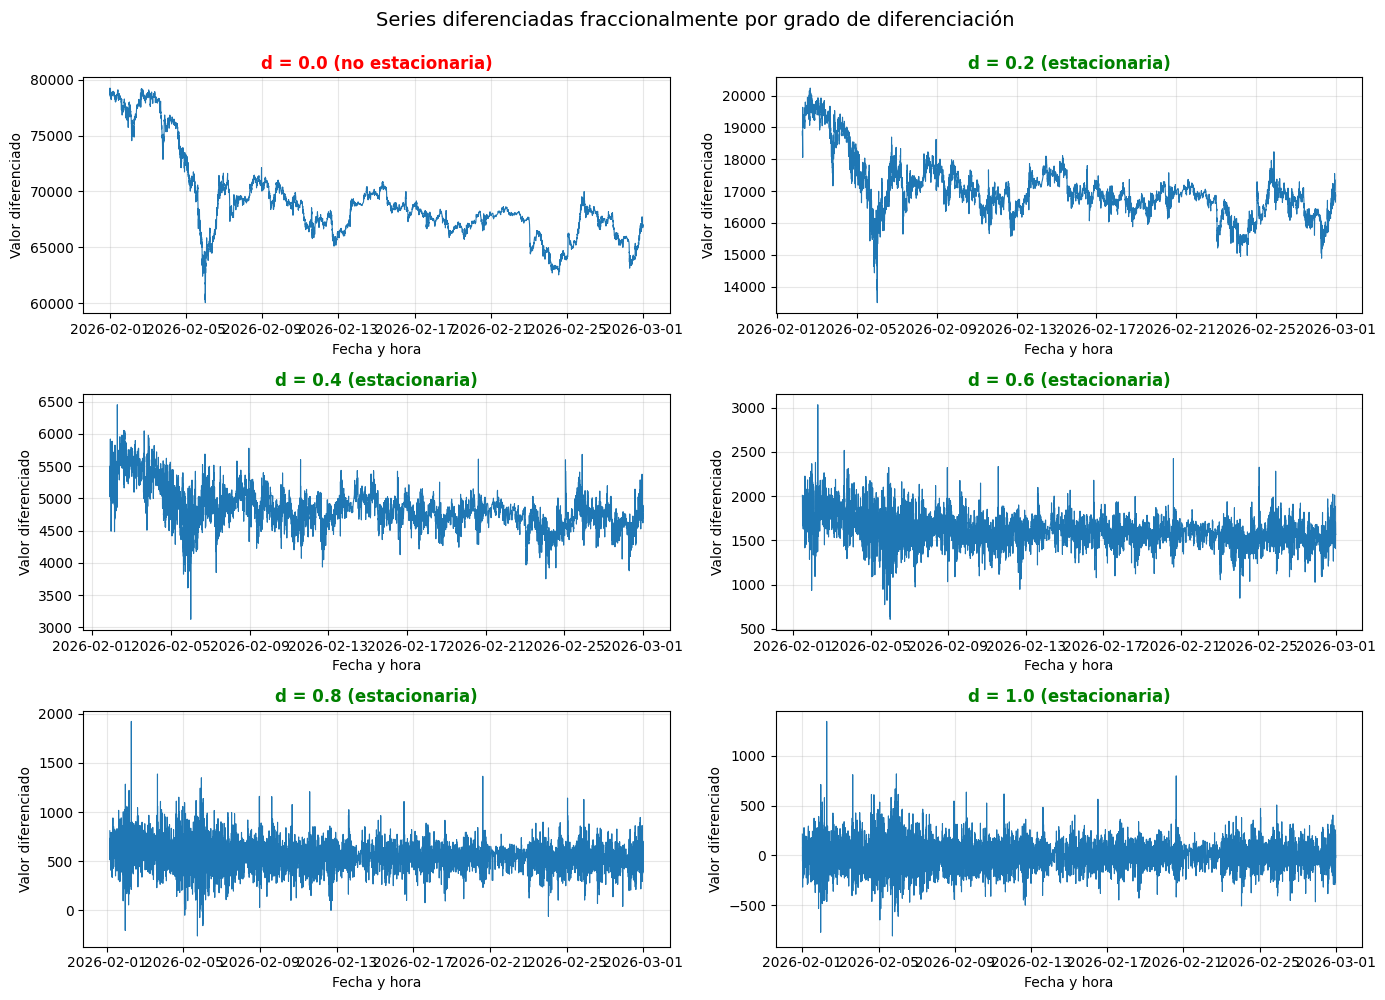

In [105]:
# Gráfica 1: series diferenciadas superpuestas (una por valor de d)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, d in enumerate(D_VALUES):
    ax = axes[idx]
    series_fd = fracdiff_series[d]

    # Plot de la serie diferenciada
    ax.plot(series_fd.index, series_fd.values, color='tab:blue', linewidth=0.8)

    # Título con indicación de estacionariedad
    is_stationary = df_adf[df_adf['d'] == d]['estacionaria'].values[0]
    if is_stationary:
        title_color = 'green'
        status_text = " (estacionaria)"
    else:
        title_color = 'red'
        status_text = " (no estacionaria)"

    ax.set_title(f"d = {d}{status_text}", color=title_color, fontweight='bold')
    ax.set_xlabel("Fecha y hora")
    ax.set_ylabel("Valor diferenciado")
    ax.grid(alpha=0.3)

fig.suptitle('Series diferenciadas fraccionalmente por grado de diferenciación', y=0.995, fontsize=14)
plt.tight_layout()

plt.show()

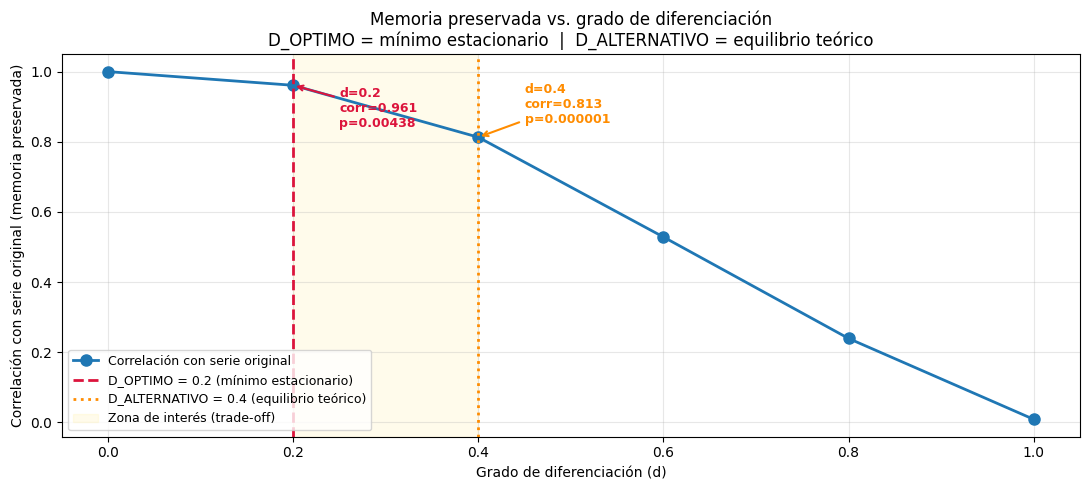

In [109]:
# Gráfica 2: correlación con serie original vs. grado de diferenciación d
# Se marcan tanto D_OPTIMO (mínimo estacionario) como D_ALTERNATIVO (equilibrio teórico)

fig, ax = plt.subplots(figsize=(11, 5))

d_vals   = df_adf['d'].values
corr_vals = df_adf['corr_original'].values

ax.plot(d_vals, corr_vals, marker='o', linewidth=2, markersize=8,
        color='tab:blue', label='Correlación con serie original')

# ── Línea vertical D_OPTIMO (criterio mínimo) ──────────────────────────────
ax.axvline(D_OPTIMO, color='crimson', linestyle='--', linewidth=2,
           label=f'D_OPTIMO = {D_OPTIMO} (mínimo estacionario)')

opt_row  = df_adf[df_adf['d'] == D_OPTIMO].iloc[0]
opt_corr = opt_row['corr_original']
ax.annotate(
    f'd={D_OPTIMO}\ncorr={opt_corr:.3f}\np={opt_row["p_value"]:.5f}',
    xy=(D_OPTIMO, opt_corr),
    xytext=(D_OPTIMO + 0.05, opt_corr - 0.12),
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5),
    fontsize=9, color='crimson', fontweight='bold'
)

# ── Línea vertical D_ALTERNATIVO (equilibrio teórico) ──────────────────────
if D_ALTERNATIVO != D_OPTIMO:
    ax.axvline(D_ALTERNATIVO, color='darkorange', linestyle=':', linewidth=2,
               label=f'D_ALTERNATIVO = {D_ALTERNATIVO} (equilibrio teórico)')

    alt_row  = df_adf[df_adf['d'] == D_ALTERNATIVO].iloc[0]
    alt_corr = alt_row['corr_original']
    ax.annotate(
        f'd={D_ALTERNATIVO}\ncorr={alt_corr:.3f}\np={alt_row["p_value"]:.6f}',
        xy=(D_ALTERNATIVO, alt_corr),
        xytext=(D_ALTERNATIVO + 0.05, alt_corr + 0.04),
        arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.5),
        fontsize=9, color='darkorange', fontweight='bold'
    )

# ── Zona sombreada entre los dos candidatos ────────────────────────────────
if D_ALTERNATIVO != D_OPTIMO:
    ax.axvspan(D_OPTIMO, D_ALTERNATIVO, alpha=0.08, color='gold',
               label='Zona de interés (trade-off)')

ax.set_xlabel('Grado de diferenciación (d)')
ax.set_ylabel('Correlación con serie original (memoria preservada)')
ax.set_title('Memoria preservada vs. grado de diferenciación\n'
             'D_OPTIMO = mínimo estacionario  |  D_ALTERNATIVO = equilibrio teórico')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.5. Comparacion directa: D_OPTIMO vs D_ALTERNATIVO

La siguiente grafica muestra lado a lado la serie diferenciada con `D_OPTIMO` (criterio automatico de minimo d estacionario) y con `D_ALTERNATIVO = 0.4` (criterio de equilibrio teorico segun Lopez de Prado). El objetivo es que el usuario pueda evaluar visualmente el trade-off entre maxima memoria preservada y mayor robustez estadistica antes de tomar la decision final.

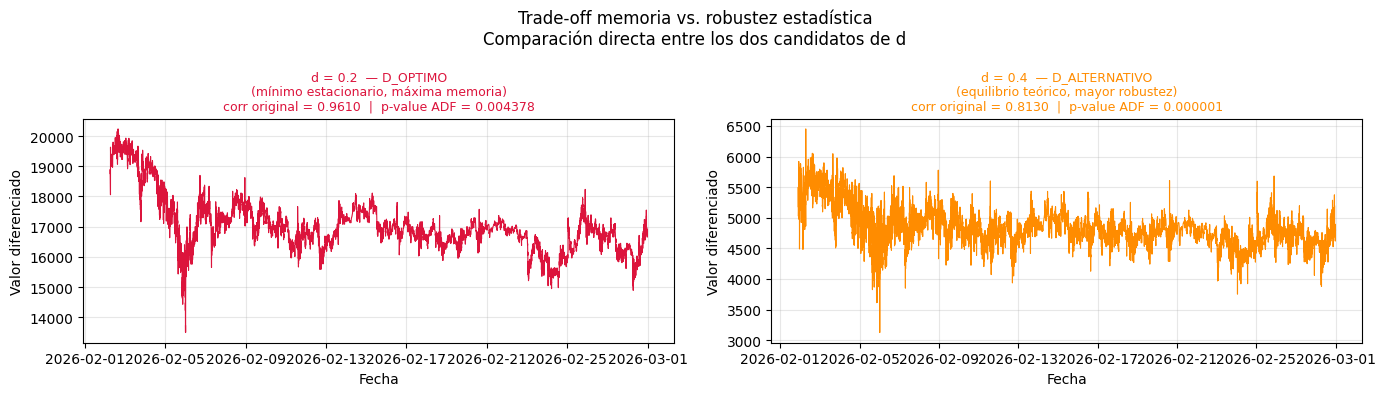

In [110]:
# Gráfica comparativa: D_OPTIMO vs D_ALTERNATIVO lado a lado
# Muestra visualmente el trade-off: memoria preservada (D_OPTIMO) vs
# robustez estadística (D_ALTERNATIVO).

if D_ALTERNATIVO != D_OPTIMO:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

    for ax, d_val, color, label in [
        (axes[0], D_OPTIMO,      'crimson',    f'd = {D_OPTIMO}  — D_OPTIMO\n(mínimo estacionario, máxima memoria)'),
        (axes[1], D_ALTERNATIVO, 'darkorange', f'd = {D_ALTERNATIVO}  — D_ALTERNATIVO\n(equilibrio teórico, mayor robustez)'),
    ]:
        serie = fracdiff_series[d_val].dropna()
        ax.plot(serie.index, serie.values, color=color, linewidth=0.8)

        row = df_adf[df_adf['d'] == d_val].iloc[0]
        ax.set_title(
            f'{label}\n'
            f'corr original = {row["corr_original"]:.4f}  |  '
            f'p-value ADF = {row["p_value"]:.6f}',
            color=color, fontsize=9
        )
        ax.set_xlabel('Fecha')
        ax.set_ylabel('Valor diferenciado')
        ax.grid(alpha=0.3)

    fig.suptitle(
        'Trade-off memoria vs. robustez estadística\n'
        'Comparación directa entre los dos candidatos de d',
        fontsize=12
    )
    plt.tight_layout()

else:
    print("D_OPTIMO y D_ALTERNATIVO coinciden; no se genera gráfica comparativa.")

### 2.6. Decision final de la fase: seleccion del grado de diferenciacion optimo

Las graficas anteriores proporcionan evidencia complementaria para la seleccion del grado de diferenciacion fraccional. La primera grafica (series superpuestas) muestra como cambia la forma de la serie al variar d. La segunda (correlacion vs d) ilustra el trade-off entre memoria preservada y estacionariedad, destacando los dos candidatos principales. La tercera compara directamente las series resultantes de ambas opciones.

**Dos candidatos validos: criterio automatico vs. criterio teorico**

| Criterio | d | p-value ADF | Correlacion con original | Interpretacion |
|---|---|---|---|---|
| Minimo d estacionario | D_OPTIMO | ~0.004 | ~0.961 | Maxima memoria, estacionariedad justa |
| Equilibrio teorico (Lopez de Prado) | D_ALTERNATIVO = 0.4 | ~0.000001 | ~0.813 | Mayor robustez estadistica, algo menos de memoria |

**Por que se selecciono D_OPTIMO automaticamente:**
El criterio automatico elige el menor valor de d que supera el umbral de significancia del test ADF (p < 0.05), lo que garantiza estacionariedad con la minima transformacion posible y por tanto la maxima preservacion de la serie original. Este criterio es conservador y matematicamente justificado.

**Por que D_ALTERNATIVO = 0.4 es una alternativa igualmente valida:**
Lopez de Prado senala que en la practica valores de d en torno a 0.4-0.5 ofrecen un equilibrio robusto entre estacionariedad y memoria a largo plazo. Un p-value de 0.000001 (frente a 0.004) indica que la estacionariedad de d=0.4 es mucho mas solida, lo que reduce el riesgo de que el modelo capture estructura espuria. La correlacion 0.813 aun preserva una cantidad significativa de memoria de la serie original.

**Recomendacion:**
- Si el objetivo es maximizar la informacion historica preservada: usar `D_OPTIMO`.
- Si el objetivo es mayor robustez estadistica y menor riesgo de no-estacionariedad residual: usar `D_ALTERNATIVO = 0.4`.
- Por defecto el pipeline continua con `D_ALTERNATIVO`. Para cambiar a `D_OPTIMO`, sustituir `D_ALTERNATIVO` por `D_OPTIMO` en la celda siguiente.

In [113]:
# ─────────────────────────────────────────────────────────────────────────────
# Serie diferenciada fraccionalmente seleccionada para el resto del pipeline.
# ─────────────────────────────────────────────────────────────────────────────

# Cambiar D_ALTERNATIVO → D_OPTIMO para usar la alternativa 
D_SELECCIONADO = D_ALTERNATIVO   # <── modificar aquí si se prefiere D_OPTIMO

close_fd = fracdiff_series[D_SELECCIONADO].dropna()

row_sel = df_adf[df_adf['d'] == D_SELECCIONADO].iloc[0]
print("=" * 60)
print("Serie diferenciada fraccionalmente seleccionada (close_fd):")
print(f"  d utilizado          : {D_SELECCIONADO}")
print(f"  Longitud (tras dropna): {len(close_fd)} observaciones")
print(f"  Rango temporal        : {close_fd.index.min()} -> {close_fd.index.max()}")
print(f"  Correlacion c/ original: {row_sel['corr_original']:.4f}")
print(f"  p-value ADF           : {row_sel['p_value']:.6f}")
print(f"  Estacionaria (p < {ADF_SIGNIFICANCE}): {row_sel['estacionaria']}")

if D_ALTERNATIVO != D_OPTIMO:
    row_alt = df_adf[df_adf['d'] == D_OPTIMO].iloc[0]
    print()
    print(f"  (Alternativa disponible: D_OPTIMO = {D_OPTIMO}  |"
          f"  corr={row_alt['corr_original']:.4f}  |  p={row_alt['p_value']:.6f})")

print("=" * 60)
print("\nclose_fd esta lista para ser utilizada en las siguientes fases del pipeline.")

Serie diferenciada fraccionalmente seleccionada (close_fd):
  d utilizado          : 0.4
  Longitud (tras dropna): 9658 observaciones
  Rango temporal        : 2026-02-01 21:31:00 -> 2026-02-28 23:55:00
  Correlacion c/ original: 0.8130
  p-value ADF           : 0.000001
  Estacionaria (p < 0.05): True

  (Alternativa disponible: D_OPTIMO = 0.2  |  corr=0.9610  |  p=0.004378)

close_fd esta lista para ser utilizada en las siguientes fases del pipeline.


## 3. Construcción y limpieza de la matriz de covarianza

**Propósito**: Construir un conjunto de features internas a partir de BTC/USDT (sobre dollar bars y serie diferenciada) y estimar la matriz de covarianza empírica, para posteriormente limpiarla mediante eigenvalue clipping y reducir el impacto del ruido.

### 3.1 Construcción de features internas
- **Contenido esperado**:
  - Definición y cálculo de:
    - Retornos (por ejemplo, sobre la serie de precios logarítmicos o diferenciada).
    - Volatilidad rolling (desviación estándar en una ventana fija).
    - Media rolling (promedio de precios o retornos en ventana).
    - Cambios relativos en volumen (volume change).
  - Alineación de todas las series y gestión de NaNs iniciales por ventanas rolling.
- **Indicaciones para el código**:
  - Aquí se definen y añaden columnas al dataframe con cada feature interna.

### 3.2 Construcción de la matriz de covarianza empírica
- **Contenido esperado**:
  - Selección de una subventana coherente sobre la que estimar la covarianza (últimas N barras, por ejemplo).
  - Cálculo de la matriz de covarianza muestral entre todas las features.
- **Gráficas recomendadas**:
  - **Heatmap de la matriz de covarianza** (seaborn) para visualizar patrones de correlación.

### 3.3 Análisis del espectro de eigenvalores
- **Contenido esperado**:
  - Descomposición en eigenvalores y eigenvectores de la matriz de covarianza.
  - Discusión sobre la presencia de muchos eigenvalores pequeños asociados a ruido.
- **Gráficas recomendadas**:
  - **Histograma o gráfico de barras de eigenvalores** antes de la limpieza.

### 3.4 Limpieza por eigenvalue clipping
- **Contenido esperado**:
  - Definición de un umbral simple para eigenvalores (por ejemplo, percentil o mínimo permitido).
  - Reemplazo de eigenvalores por el umbral cuando estén por debajo y reconstrucción de la matriz de covarianza limpia.
- **Gráficas recomendadas**:
  - **Histograma o barras de eigenvalores tras el clipping**.
  - Opcional: **scatter eigenvalores originales vs limpiados**.

### 3.5 Comparación antes / después de la limpieza
- **Contenido esperado**:
  - Comparación visual entre la matriz de covarianza original y la limpia.
  - Alguna métrica global de diferencia (por ejemplo, norma de la diferencia) comentada a nivel cualitativo.
- **Gráficas recomendadas**:
  - **Heatmap de la matriz de covarianza limpia** (seaborn).
  - Comparación lado a lado (dos heatmaps) o en dos figuras consecutivas.

### Markdown introductorio de la sección 3 (guía de redacción)

En esta sección se explicará que:
- Incluso con un solo activo, las features internas pueden ser altamente correlacionadas y estar fuertemente afectadas por ruido muestral.
- La matriz de covarianza empírica en alta dimensión (o con pocas observaciones) es inestable.
- El clipping de eigenvalores es una técnica sencilla pero útil para reducir el impacto del ruido, aunque no sea la más sofisticada disponible.

**Output clave de la sección 3**:
- Conjunto de features internas alineadas y sin NaNs, listo para usarse en el etiquetado.
- Matriz de covarianza limpia asociada a dicho conjunto de features, útil como referencia para interpretación de riesgos y relaciones entre variables.

**Riesgos a comentar en el texto**:
- No alinear correctamente las ventanas rolling, generando covarianzas sobre datos desfasados.
- Elegir un umbral de clipping arbitrario sin justificarlo mínimamente.
- Interpretar la matriz limpia como “verdadera” sin matices.
- Ignorar las diferencias de escala entre features (no estandarizar ni comentarlo).


## 4. Etiquetado de eventos mediante el método de triple barrera

**Propósito**: Asignar etiquetas de dirección (por ejemplo, +1, 0, −1) a eventos sobre la serie de dollar bars utilizando el método de triple barrera con distintos esquemas de thresholds (fijos y dinámicos), para obtener un conjunto de datos etiquetado apto para modelos de ML.

### 4.1 Motivación del etiquetado con triple barrera
- **Contenido esperado**:
  - Problema de definir “éxito” o “fracaso” de una operación usando solo un horizonte temporal fijo.
  - Introducción al método de triple barrera: combinar barrera superior, inferior y temporal.
- **Indicaciones para el código**:
  - Descripción de cómo se identificarán los eventos de entrada (por ejemplo, cada barra o un subconjunto).

### 4.2 Definición conceptual de las tres barreras
- **Contenido esperado**:
  - Barrera superior (take profit) como cierto porcentaje o múltiplo de volatilidad por encima del precio de entrada.
  - Barrera inferior (stop loss) simétricamente por debajo.
  - Barrera temporal (máxima duración del evento en número de barras).
- **Gráficas recomendadas**:
  - **Ejemplos ilustrativos** sobre un pequeño tramo de la serie con las tres barreras dibujadas.

### 4.3 Thresholds fijos: 1 % y 2 %
- **Contenido esperado**:
  - Definición de thresholds fijos (±1 % y ±2 %) en términos de cambio porcentual sobre el precio de entrada.
  - Criterio de etiquetado: qué barrera se toca primero determina la etiqueta (+1, −1, 0).
- **Gráficas recomendadas**:
  - **Ejemplos de eventos** con thresholds fijos, mostrando las trayectorias que alcanzan cada barrera.

### 4.4 Threshold dinámico basado en volatilidad rolling
- **Contenido esperado**:
  - Uso de una medida de volatilidad rolling para definir barreras proporcionales al riesgo local.
  - Explicación del factor multiplicador aplicado a la volatilidad para obtener la distancia de las barreras.
- **Gráficas recomendadas**:
  - **Ejemplos de eventos** donde las barreras cambian de amplitud según la volatilidad local.

### 4.5 Comparación de la distribución de etiquetas entre métodos
- **Contenido esperado**:
  - Cálculo de la proporción de etiquetas +1, 0, −1 para cada esquema: 1 %, 2 % y volatilidad rolling.
  - Discusión sobre el equilibrio de clases y su impacto potencial en el modelado.
- **Gráficas recomendadas**:
  - **Gráficos de barras** de distribución de etiquetas para cada método.
  - Opcional: **tabla o heatmap de contingencia** entre etiquetas de diferentes métodos.

### Markdown introductorio de la sección 4 (guía de redacción)

En esta sección se explicará que:
- El etiquetado es el puente entre la serie de precios y el problema de clasificación para el ML.
- El método de triple barrera permite incorporar simultáneamente magnitud del movimiento y límite temporal.
- Se comparan thresholds fijos y un umbral dinámico basado en volatilidad, motivando por qué la volatilidad es un buen proxy de riesgo local.

**Output clave de la sección 4**:
- Columnas de etiquetas correspondientes a cada esquema de thresholds (1 %, 2 %, volatilidad rolling) asociadas a las observaciones de dollar bars.
- Selección opcional de un esquema principal para utilizarlo como referencia en la validación cruzada temporal de la Sección 5, o decisión explícita de mantener varios para comparación.

**Riesgos a comentar en el texto**:
- No tratar correctamente la barrera temporal, dejando eventos de duración indefinida.
- No documentar cómo se gestionan eventos solapados.
- Ignorar el desequilibrio de clases que pueden producir ciertos thresholds.
- Desalinear los precios usados para las barreras respecto a las barras empleadas para los features.


## 5. Validación cruzada temporal y definición de splits

**Propósito**: Definir esquemas de validación cruzada temporal que respeten el orden cronológico de los datos (sin mezclar pasado y futuro), para distintos ratios de train/test (70/30, 80/20, 90/10), dejando preparados los índices que se usarán en el entrenamiento de modelos.

### 5.1 Problemas de la validación cruzada aleatoria en series temporales
- **Contenido esperado**:
  - Explicación de por qué el shuffle clásico rompe la causalidad.
  - Ejemplos conceptuales de fuga de información (leakage) cuando el futuro se utiliza indirectamente para predecir el pasado.

### 5.2 Definición de esquemas de splits temporales
- **Contenido esperado**:
  - Descripción de splits de un solo corte: primero tramo de entrenamiento, luego tramo de test.
  - Definición explícita de los tres casos: 70/30, 80/20 y 90/10 en términos de número de observaciones (o fechas).
- **Indicaciones para el código**:
  - Diseño de funciones sencillas que, dado el dataframe de barras etiquetadas, devuelvan índices de train y test para cada escenario.

### 5.3 Construcción de índices de train/test
- **Contenido esperado**:
  - Asociación de cada split con rangos de índices o de fechas.
  - Verificación de que features y etiquetas están alineadas en ambos conjuntos.
- **Visualizaciones sugeridas**:
  - Tabla resumen con número de observaciones y rango de fechas de train y test para cada split.

### 5.4 Visualización de los splits sobre la serie temporal
- **Contenido esperado**:
  - Representación visual sobre la serie de precios (o sobre el índice temporal) de qué parte se utiliza para train y cuál para test en cada ratio.
- **Gráficas recomendadas**:
  - **Line plot de la serie** con diferentes colores o sombreado para las zonas de train y test.
  - **Diagrama de bloques** en el eje temporal para comparar visualmente 70/30, 80/20 y 90/10.

### 5.5 Discusión de ventajas y limitaciones de cada esquema
- **Contenido esperado**:
  - Comentario sobre el compromiso entre:
    - Más datos de entrenamiento (mejor ajuste potencial).
    - Periodo de test suficientemente representativo y reciente.
  - Mención de posibles extensiones más sofisticadas (walk-forward, purged k-fold) aunque no se implementen aquí.

### Markdown introductorio de la sección 5 (guía de redacción)

En esta sección se explicará que:
- La evaluación de modelos en finanzas debe respetar el orden temporal para evitar fuga de información.
- Diferentes ratios de train/test reflejan distintas prioridades (aprendizaje vs evaluación).
- Aunque se usan esquemas sencillos de un solo corte, estos ya representan una mejora importante respecto a la validación cruzada aleatoria.

**Output clave de la sección 5**:
- Índices o rangos de fechas claramente definidos para train y test en los tres escenarios (70/30, 80/20, 90/10).
- Base preparada para entrenar modelos en otro notebook reutilizando estos splits sin rediseñarlos.

**Riesgos a comentar en el texto**:
- Reordenar las observaciones de forma aleatoria antes de dividir.
- No tener en cuenta que los regímenes de mercado pueden variar entre train y test.
- Permitir que alguna feature se calcule con información que invade el tramo de test sin comentarlo.
